In [8]:
from TradingEnv import StockTradingEnv
from pybroker import YFinance
import pybroker
pybroker.enable_data_source_cache('yfinance')
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy 
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold  
import os 

In [5]:
yfinance = YFinance()
df = yfinance.query(['AAPL'], start_date='3/1/2021', end_date='3/1/2026')
df['date'] = pd.to_datetime(df['date']).dt.date
env = StockTradingEnv(df, initial_balance=100000, commission_fee=0.0001, slippage_cost=0.005)


Loading bar data...


[*********************100%***********************]  1 of 1 completed

Loaded bar data: 0:00:02 



In [10]:
save_path = os.path.join('Training', 'Saved Models')
os.makedirs(save_path, exist_ok=True)
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=480, verbose=1)
eval_callback = EvalCallback(
    env,                             
    callback_on_new_best=stop_callback,
    eval_freq=10000,
    best_model_save_path=save_path,       
    verbose=1
)

In [12]:
model = PPO('MlpPolicy' ,  env, verbose = 1 ,device = 'mps')


Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [13]:
model.learn(total_timesteps=100000 , progress_bar=True , callback=eval_callback)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.26e+03 |
|    ep_rew_mean     | -1e+03   |
| time/              |          |
|    fps             | 244      |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.26e+03     |
|    ep_rew_mean          | -682         |
| time/                   |              |
|    fps                  | 197          |
|    iterations           | 2            |
|    time_elapsed         | 20           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0029226318 |
|    clip_fraction        | 0.0569       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | -5.01e-06    |
|    learning_r

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/stable_baselines3/common/evaluation
.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=10000, episode_reward=-1.72 +/- 0.00

Episode length: 1256.00 +/- 0.00

...

Episode length: 1256.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 1.26e+03    |
|    mean_reward          | -1.72       |
| time/                   |             |
|    total_timesteps      | 90000       |
| train/                  |             |
|    approx_kl            | 0.008401608 |
|    clip_fraction        | 0.0481      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.66       |
|    explained_variance   | 0           |
|    learning_rate        | 0.0003      |
|    loss                 | 5.4e+04     |
|    n_updates            | 430         |
|    policy_gradient_loss | -0.00109    |
|    std                  | 0.913       |
|    value_loss           | 1.14e+05    |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.41e+03 |
|    ep_rew_mean     | 3.39e+03 |
| time/              |          |
|    fps             | 101      

Eval num_timesteps=100000, episode_reward=-1.72 +/- 0.00

Episode length: 1256.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 1.26e+03     |
|    mean_reward          | -1.72        |
| time/                   |              |
|    total_timesteps      | 100000       |
| train/                  |              |
|    approx_kl            | 0.0033054145 |
|    clip_fraction        | 0.0184       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.65        |
|    explained_variance   | 1.19e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 8.73e+04     |
|    n_updates            | 480          |
|    policy_gradient_loss | -0.00121     |
|    std                  | 0.911        |
|    value_loss           | 1.68e+05     |
------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.41e+03 |
|    ep_rew_mean     | 3.91e+03 |
| time/              |          |
|    fps     

In [14]:
model.save('Trading_model')

Loaded cached bar data.

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
0 [0.]
1 [-0.0121503]
2 [-0.01349902]
3 [-0.01268434]
4 [-0.00777423]
5 [-0.00610656]
6 [-0.00659205]
7 [-0.00636201]
8 [-0.00533864]
9 [-0.00421002]
10 [-0.00420268]
11 [-0.00438921]
12 [-0.00456276]
13 [-42.945488]
14 [9.860965]
15 [398.1004]
16 [150.29172]
17 [372.17392]
18 [57.635815]
19 [65.1219]
20 [281.42575]
21 [-94.92511]
22 [-249.18407]
23 [-23.518839]
24 [314.0642]
25 [-256.21765]
26 [-247.54333]
27 [23.995255]
28 [-161.06903]
29 [-346.6568]
30 [155.05775]
31 [225.29611]
32 [-426.29813]
33 [-18.607294]
34 [199.94844]
35 [-14.797464]
36 [-79.54389]
37 [-366.6082]
38 [87.059456]
39 [-479.25586]
40 [-17.908426]
41 [556.26666]
42 [-468.6515]
43 [24.16916]
44 [118.77272]
45 [516.6833]
46 [-725.9196]
47 [57.97549]
48 [-399.23642]
49 [185.44394]
50 [-577.6201]
51 [-266.59894]
52 [298.91196]
53 [-99.86872]
54 [202.72098]
55 [-194.94603]
56 [-76.10891]
57 [5.0322604]
58 [113.56745]
5

/Users/alikhalidalikhalid/Trading_with_Rein/TradingEnv.py:101: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(


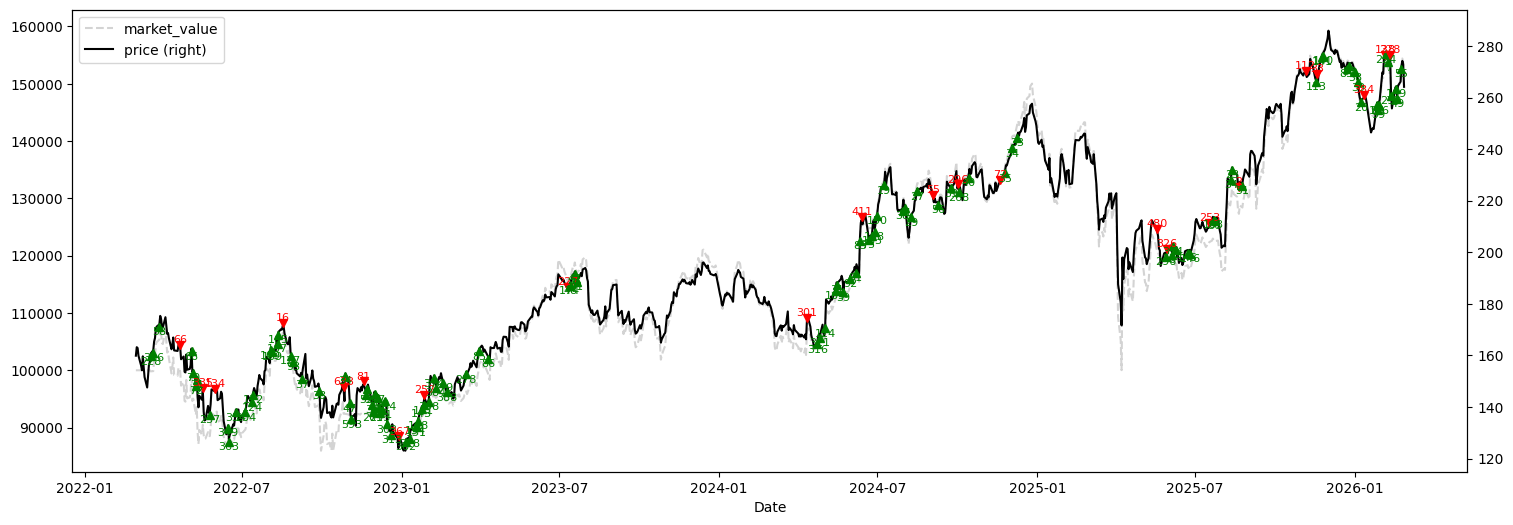

In [17]:
yfinance = YFinance()
df = yfinance.query(['AAPL'], start_date='3/1/2022', end_date='3/1/2026')
df['date'] = pd.to_datetime(df['date']).dt.date
env = StockTradingEnv(df, initial_balance=100000, commission_fee=0.0001, slippage_cost=0.005)

model = PPO.load("Trading_model", env=env)

vec_env = model.get_env()
obs = vec_env.reset()
for i in range(len(df['adj_close'])):
    action, _state = model.predict(obs)
    obs, reward, done, info = vec_env.step(action)
    print(i , reward)

env.render_all()